<a href="https://colab.research.google.com/github/fotomain/aigoogle3-results/blob/main/AiGoogl3_REGRESSION_PENGUINS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
### YOUR CODE HERE ###
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/py_csv/penguins.csv'
d = pd.read_csv(file_path)

In [4]:
#d.head()

In [5]:
penguins_final = d.dropna()
penguins_final.reset_index(inplace=True, drop=True)
# penguins_final

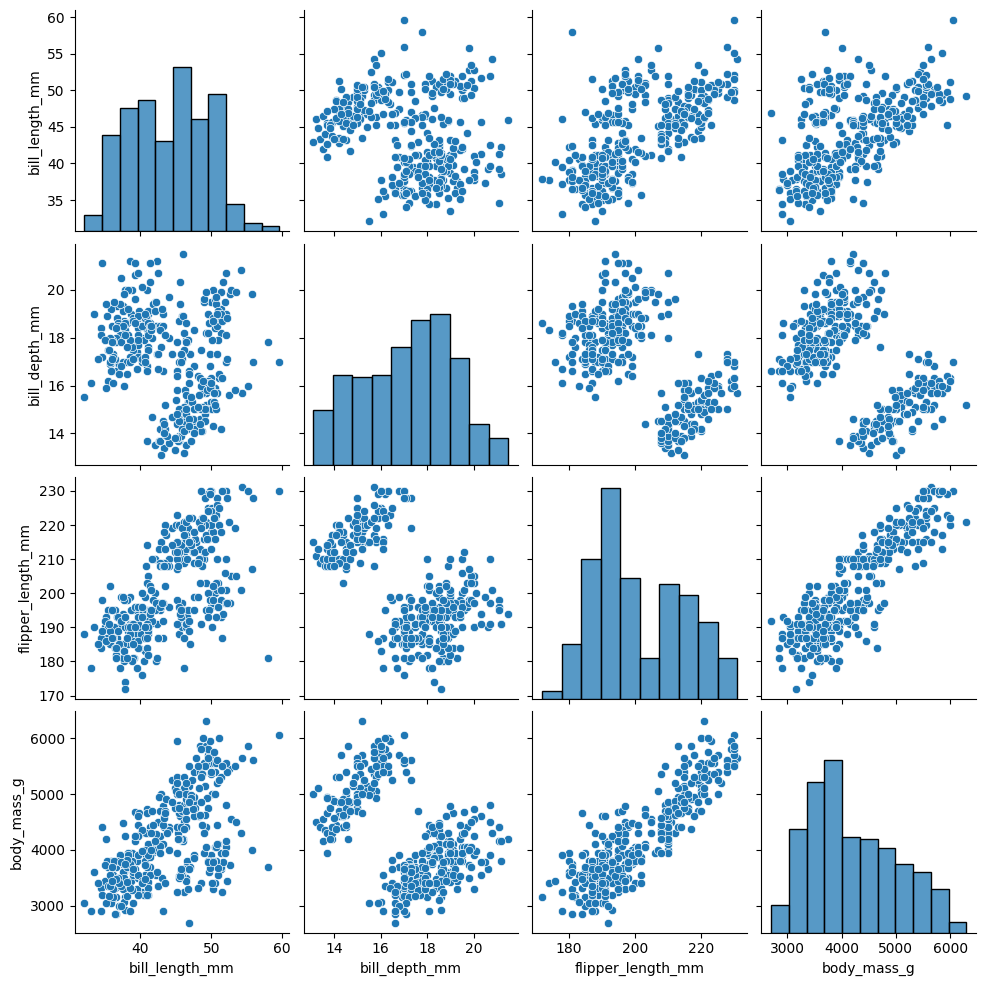

In [6]:
sns.pairplot(penguins_final)

In [7]:
ols_data=penguins_final[["bill_length_mm","body_mass_g"]]

In [8]:
ols_formula="body_mass_g ~ bill_length_mm"

In [9]:
OLS = ols(formula=ols_formula, data=ols_data)
model=OLS.fit()

In [10]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.347
Model:                            OLS   Adj. R-squared:                  0.345
Method:                 Least Squares   F-statistic:                     176.2
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           1.54e-32
Time:                        09:52:29   Log-Likelihood:                -2629.1
No. Observations:                 333   AIC:                             5262.
Df Residuals:                     331   BIC:                             5270.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        388.8452    289.817      1.342      0.181    -181.271     958.961
bill_length_mm    86.7918      6.538     13.276      0.000      73.931      99.652
==============================================================================
Omnibus:                        6.141   Durbin-Watson:                   0.845
Prob(Omnibus):                  0.046   Jarque-Bera (JB):                4.899
Skew:                          -0.197   Prob(JB):                       0.0864
Kurtosis:                       2.555   Cond. No.                         360.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
x=ols_data["bill_length_mm"]
fitted_values = model.predict(x)

In [12]:
residuals = model.resid

<Axes: xlabel='bill_length_mm', ylabel='body_mass_g'>

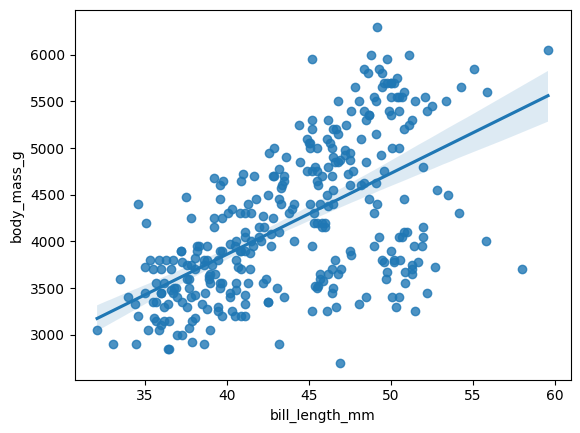

In [13]:
sns.regplot(x="bill_length_mm",y="body_mass_g", data=ols_data)

Text(0, 0.5, 'Residuals')

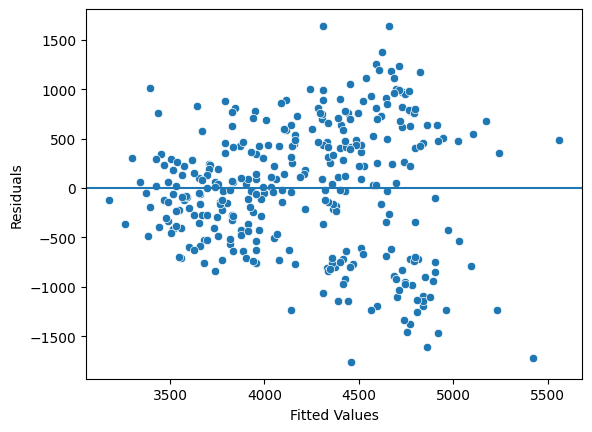

In [14]:
fig=sns.scatterplot(x=fitted_values,y=residuals)
fig.axhline(0)
fig.set_xlabel("Fitted Values")
fig.set_ylabel("Residuals")
fig.set_ylabel("Residuals")


Text(0.5, 1.0, 'Histogram of Residuals')

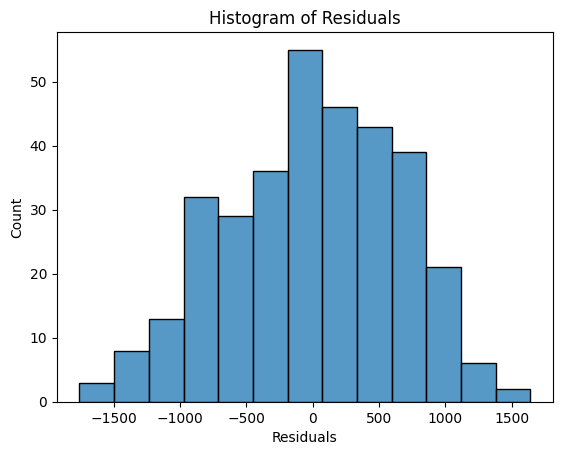

In [15]:
fig = sns.histplot(residuals)
fig.set_xlabel("Residuals")
fig.set_title("Histogram of Residuals")


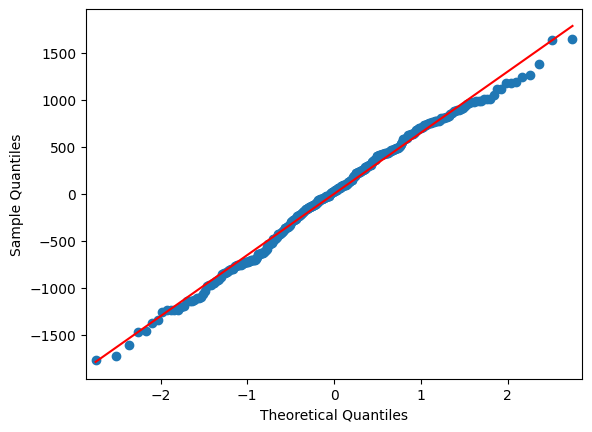

In [16]:
fig=sm.qqplot(model.resid, line="s")
plt.show()

In [17]:
#████████████
#████████████ penguins MULTIPLE REGRESSION
#████████████

In [25]:
penguins=penguins_final[["body_mass_g","bill_length_mm","sex", "species"]].copy()
penguins.columns=["body_mass_g","bill_length_mm","gender","species"]
penguins.dropna(inplace=True)
penguins

,body_mass_g,bill_length_mm,gender,species
0,3750.0,39.1,male,Adelie
1,3800.0,39.5,female,Adelie
2,3250.0,40.3,female,Adelie
3,3450.0,36.7,female,Adelie
4,3650.0,39.3,male,Adelie
...,...,...,...,...
328,4925.0,47.2,female,Gentoo
329,4850.0,46.8,female,Gentoo
330,5750.0,50.4,male,Gentoo
331,5200.0,45.2,female,Gentoo


In [28]:
penguins_X=penguins[["bill_length_mm","gender", "species"]]
penguins_Y=penguins[["body_mass_g"]].copy()

In [38]:
X_train, X_test, y_train, y_test = train_test_split(penguins_X, penguins_Y, test_size=0.3, random_state=42)

In [37]:
ols_formula2="body_mass_g ~ bill_length_mm + C(gender) + C(species)"

In [35]:
ols_data2=pd.concat([X_train, y_train], axis=1)

In [39]:
OLS2=ols(formula=ols_formula2, data=ols_data2)
model2=OLS2.fit()

In [41]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     322.6
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           1.31e-92
Time:                        10:11:27   Log-Likelihood:                -1671.7
No. Observations:                 233   AIC:                             3353.
Df Residuals:                     228   BIC:                             3371.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                2032.2111    354.087      5.739      0.000    1334.510    2729.913
C(gender)[T.male]         528.9508     55.105      9.599      0.000     420.371     637.531
C(species)[T.Chinstrap]  -285.3865    106.339     -2.684      0.008    -494.920     -75.853
C(species)[T.Gentoo]     1081.6246     94.953     11.391      0.000     894.526    1268.723
bill_length_mm             35.5505      9.493      3.745      0.000      16.845      54.256
==============================================================================
Omnibus:                        0.339   Durbin-Watson:                   1.948
Prob(Omnibus):                  0.844   Jarque-Bera (JB):                0.436
Skew:                           0.084   Prob(JB):                        0.804
Kurtosis:                       2.871   Cond. No.                         798.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""